In [1]:
import numpy as np
import pandas as pd

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

In [2]:
X, y = make_classification(
    n_samples=1000,        # total samples
    n_features=10,         # total features
    n_informative=6,       # useful features
    n_redundant=2,         # redundant features
    n_classes=2,           # binary classification
    random_state=42
)

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (1000, 10)
Target Shape: (1000,)


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Train Size:", X_train.shape)
print("Test Size:", X_test.shape)

Train Size: (800, 10)
Test Size: (200, 10)


In [4]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

log_accuracy = accuracy_score(y_test, y_pred_log)

print("Logistic Regression Accuracy:", log_accuracy)

Logistic Regression Accuracy: 0.8


In [5]:
dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

dt_accuracy = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.82


In [6]:
print("Logistic Regression Report")
print(classification_report(y_test, y_pred_log))

print("Decision Tree Report")
print(classification_report(y_test, y_pred_dt))

Logistic Regression Report
              precision    recall  f1-score   support

           0       0.90      0.73      0.80       113
           1       0.72      0.90      0.80        87

    accuracy                           0.80       200
   macro avg       0.81      0.81      0.80       200
weighted avg       0.82      0.80      0.80       200

Decision Tree Report
              precision    recall  f1-score   support

           0       0.91      0.76      0.83       113
           1       0.74      0.90      0.81        87

    accuracy                           0.82       200
   macro avg       0.82      0.83      0.82       200
weighted avg       0.83      0.82      0.82       200



In [7]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree"],
    "Accuracy": [log_accuracy, dt_accuracy]
})

print(results)

                 Model  Accuracy
0  Logistic Regression      0.80
1        Decision Tree      0.82


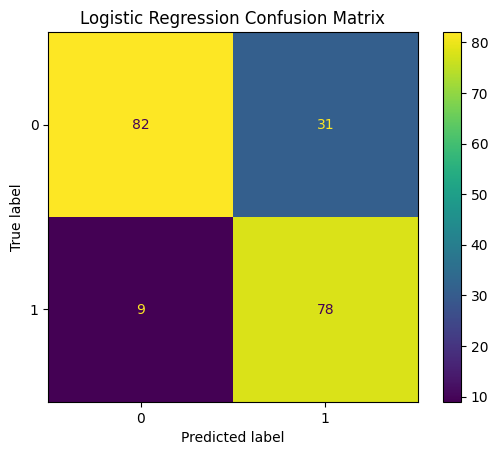

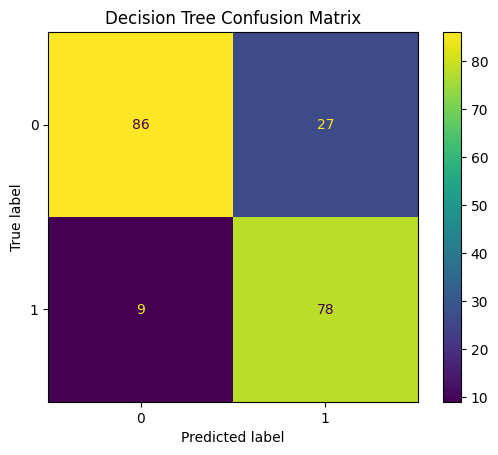

In [8]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Logistic Regression Confusion Matrix
cm_log = confusion_matrix(y_test, y_pred_log)

disp_log = ConfusionMatrixDisplay(confusion_matrix=cm_log)
disp_log.plot()

plt.title("Logistic Regression Confusion Matrix")
plt.show()


# Decision Tree Confusion Matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)

disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt)
disp_dt.plot()

plt.title("Decision Tree Confusion Matrix")
plt.show()